In [ ]:
import numpy as np
from scipy.stats import norm
from scipy.special import logsumexp
import matplotlib.pyplot as plt

class DiscreteRampHMM:
    def __init__(self, beta, sigma, dt, K=100, x_init=0.0):
        self.beta = beta
        self.sigma = sigma
        self.dt = dt
        self.K = K
        self.x_vals = np.linspace(0, 1, K)
        self.dx = 1 / (K - 1)
        self.x_init = x_init

        self.T = self._build_transition_matrix()
        self.pi = self._build_initial_distribution()

    def _build_transition_matrix(self):
        T = np.zeros((self.K, self.K))

        for s in range(self.K):
            mu = self.x_vals[s] + self.beta * self.dt
            std = self.sigma * np.sqrt(self.dt)

            for s_prime in range(self.K):
                lower = self.x_vals[s_prime] - self.dx / 2
                upper = self.x_vals[s_prime] + self.dx / 2
                T[s, s_prime] = norm.cdf(upper, mu, std) - norm.cdf(lower, mu, std)

            # Reflecting boundary at 0
            if s == 0:
                T[s, 0] += norm.cdf(0, mu, std)

            # Absorbing boundary at 1
            if s == self.K - 1:
                T[s, :] = 0
                T[s, self.K - 1] = 1.0

            # Normalize row
            T[s, :] /= T[s, :].sum()

        return T

    def _build_initial_distribution(self):
        std = self.sigma * np.sqrt(self.dt)
        pi = norm.pdf(self.x_vals, loc=self.x_init, scale=std)
        pi /= pi.sum()
        return pi

    def simulate(self, T_steps=100):
        states = np.zeros(T_steps, dtype=int)
        x_t = np.zeros(T_steps)

        states[0] = np.random.choice(self.K, p=self.pi)
        x_t[0] = self.x_vals[states[0]]

        for t in range(1, T_steps):
            states[t] = np.random.choice(self.K, p=self.T[states[t-1]])
            x_t[t] = self.x_vals[states[t]]

        return x_t

    def plot_trajectory(self, x_t):
        plt.plot(np.arange(len(x_t)) * self.dt, x_t)
        plt.xlabel("Time")
        plt.ylabel("x_t")
        plt.title("Simulated Ramp HMM Trajectory")
        plt.grid(True)
        plt.show()

# Example usage:
if __name__ == "__main__":
    model = DiscreteRampHMM(beta=0.1, sigma=0.05, dt=0.01, K=100, x_init=0.1)
    trajectory = model.simulate(T_steps=200)
    model.plot_trajectory(trajectory)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

class DiscreteRampHMM:
    def __init__(self, beta, sigma, dt, K, x0):
        self.beta = beta
        self.sigma = sigma
        self.dt = dt
        self.K = K
        self.x0 = x0
        self.grid = np.linspace(0, 1, K)
        self.T = self._build_transition_matrix()
        self.pi = self._build_initial_distribution()

    def _build_transition_matrix(self):
        T = np.zeros((self.K, self.K))
        for s in range(self.K):
            x = self.grid[s]
            mu = x + self.beta * self.dt
            std = self.sigma * np.sqrt(self.dt)

            if x == 1:
                T[s, -1] = 1.0
                continue

            for s_prime in range(self.K):
                x_next = self.grid[s_prime]
                if x > 0:
                    T[s, s_prime] = self._truncated_normal_pdf(x_next, mu, std, lower=0, upper=1)
                else:
                    if x_next == 0:
                        T[s, s_prime] = self._gaussian_cdf(0, mu, std)
                    else:
                        T[s, s_prime] = self._truncated_normal_pdf(x_next, mu, std, lower=0, upper=1)

            # Normalize row to sum to 1
            T[s] /= T[s].sum()

        return T

    def _build_initial_distribution(self):
        mu = self.x0
        std = self.sigma * np.sqrt(self.dt)
        pi = np.array([self._truncated_normal_pdf(x, mu, std, 0, 1) for x in self.grid])
        return pi / pi.sum()

    def _truncated_normal_pdf(self, x, mu, sigma, lower, upper):
        from scipy.stats import norm
        Z = norm.cdf(upper, loc=mu, scale=sigma) - norm.cdf(lower, loc=mu, scale=sigma)
        return norm.pdf(x, loc=mu, scale=sigma) / Z

    def _gaussian_cdf(self, x, mu, sigma):
        from scipy.stats import norm
        return norm.cdf(x, loc=mu, scale=sigma)

    def plot_transition_matrix(self):
        plt.figure(figsize=(8, 6))
        sns.heatmap(self.T, cmap="viridis", cbar=True, square=True)
        plt.title("Transition Matrix Heatmap")
        plt.xlabel("Next state $s'$")
        plt.ylabel("Current state $s$")
        plt.tight_layout()
        plt.show()

if __name__ == "__main__":
    hmm = DiscreteRampHMM(beta=0.1, sigma=0.2, dt=0.01, K=50, x0=0.1)
    hmm.plot_transition_matrix()


<>:56: SyntaxWarning: invalid escape sequence '\s'
<>:56: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_76960/4020570911.py:56: SyntaxWarning: invalid escape sequence '\s'
  plt.title('$x_0$={:.1f}, $\\beta$={:.0f}, $\sigma$={:.3f}'.format(x0,bet,sig))


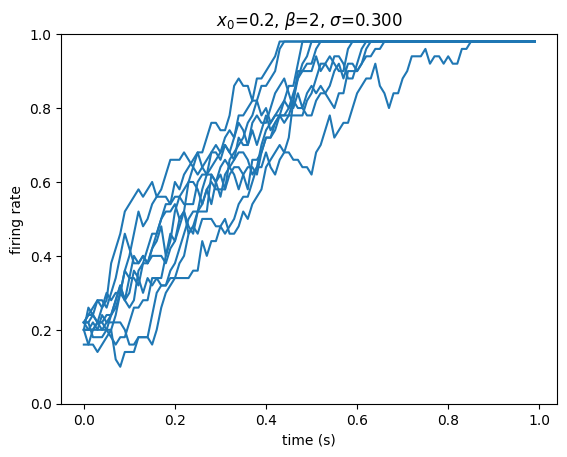

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def get_initial_distribution(K, x0, sig, dt):
    states = np.linspace(0,1,num = K)
    arr = (states - x0) / (sig*np.sqrt(dt))
    dist = normal_dist(arr)
    dist_norm = dist / np.sum(dist)    
    return dist_norm

def get_transition_matrix(K, bet, sig, dt):
    states = np.linspace(0,1,num = K)
    trans = np.empty([K,K])
    for i in range(K-1):
        arr = (states - states[i] - bet*dt) / (sig*np.sqrt(dt))
        dist = normal_dist(arr)
        dist_norm = dist / np.sum(dist)
        trans[i] = dist_norm
    trans[K-1] = np.zeros(K)
    trans[K-1][K-1] = 1
    return trans

def normal_dist(x, mean = 0, sd = 1):
    prob_density = (np.pi*sd) * np.exp(-0.5*((x-mean)/sd)**2)
    return prob_density

def simulate(init_dist, trans_matrix, length, dt, K):
    t = np.arange(length) * dt
    s = np.empty(length)
    states = np.arange(K)
    s[0] = np.random.choice(states, p = init_dist)
    for i in range (1,length):
        s[i] = np.random.choice(states, p = trans_matrix[int(s[i-1])])
    s = s / K
    return t, s

#############

K = 50
dt = 1/100

x0 = 0.2
bet = 1.5
sig = 0.3

init = get_initial_distribution(K, x0, sig, dt)
trans = get_transition_matrix(K, bet, sig, dt)

#simulate 10 trials of ramp model in one plot
for i in range(10):
    t, s = simulate(init, trans, 100, dt, K)
    plt.plot(t, s, color = 'C0')
plt.ylim(bottom = 0, top = 1)
plt.xlabel('time (s)')
plt.ylabel('firing rate')
plt.title('$x_0$={:.1f}, $\\beta$={:.0f}, $\sigma$={:.3f}'.format(x0,bet,sig))
plt.show()